In [ ]:
# Deep Learning Lab
# Exercise 1
# Implementation of a Single Layer Perceptron for a Binary Classification

# Importing necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Task 1 : Dataset Exploration
# Conversion of dataset from .txt to .csv and labelling features
df = pd.read_csv("/content/drive/MyDrive/data_banknote_authentication.txt", header=None)
df.to_csv("banknote_authentication.csv", index=False, header=False)
columns = ["Variance","Skewness","Curtosis","Entropy","Class"]
df.columns = columns
df.to_csv("banknote_authentication.csv", index=False)

In [ ]:
# Displaying Data and Descriptive statistics
df = pd.read_csv("banknote_authentication.csv")
print("\n",df.head())
print("\n",df.shape)
print("\n",df.info())
print("\n",df.isnull().sum())
print("\n",df.describe())


    Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

 (1372, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

 None

 Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

           Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353 

<Figure size 1200x800 with 0 Axes>

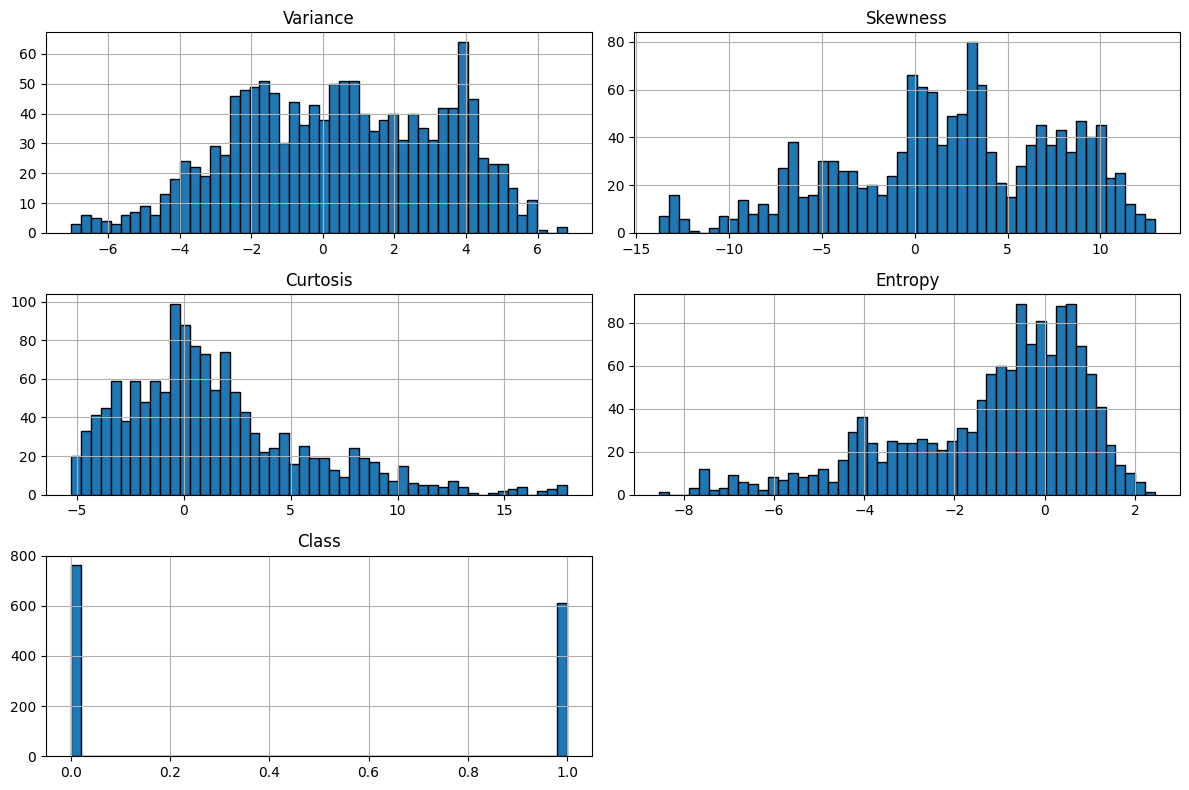

In [ ]:
# Task 2 : Exploratory Data Analysis
# Histograms plotted for each feature
plt.figure(figsize=(12, 8))
df.hist(bins=50, figsize=(12, 8), edgecolor='black')
plt.tight_layout()
plt.show()

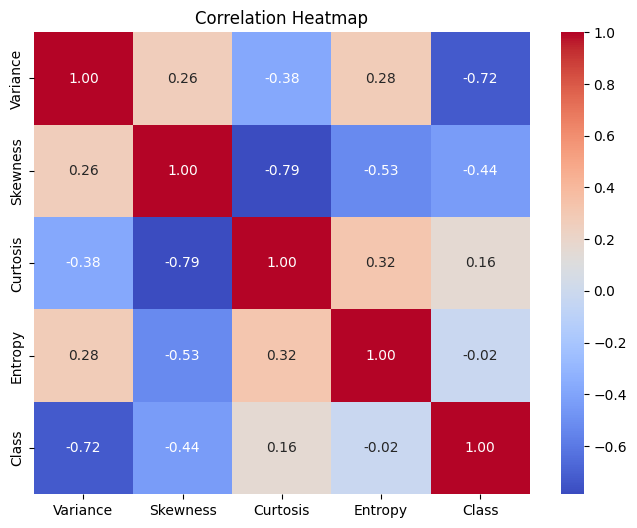

In [ ]:
# Correlation Heatmap
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

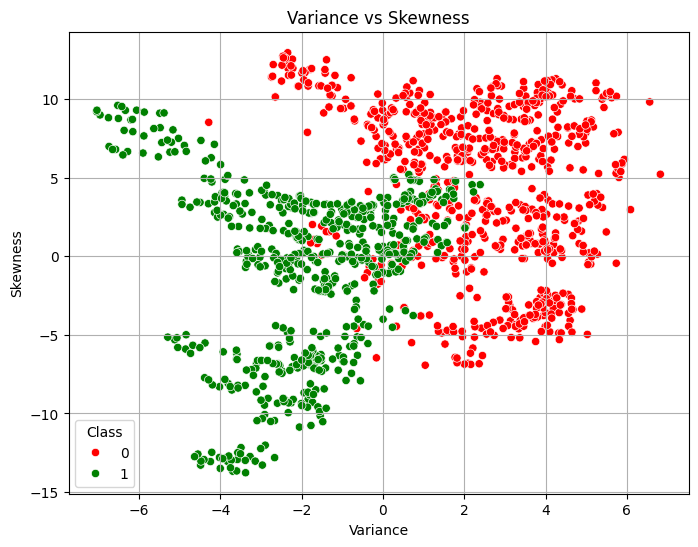

In [ ]:
# Scatterplot between two most correlated feature w.r.t the Output
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette=["red", "green"]
)

plt.title("Variance vs Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.grid(True)

plt.show()

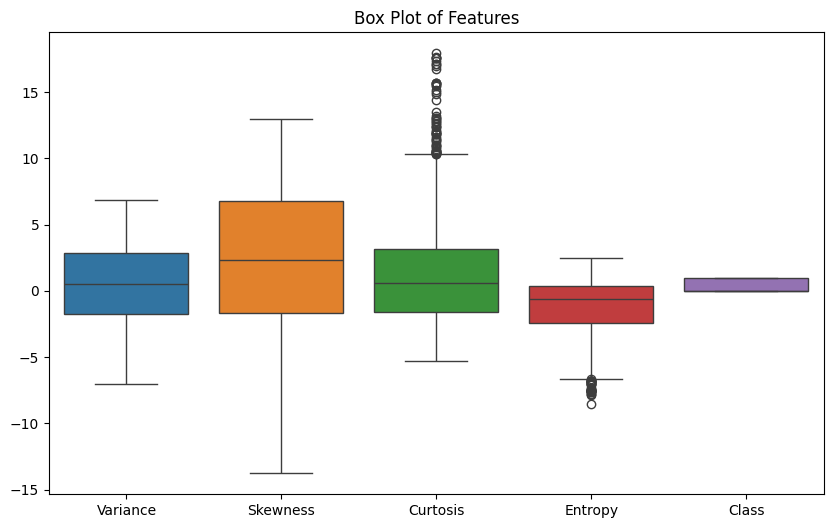

In [ ]:
# Box Plot of Features
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Box Plot of Features")
plt.show()

In [ ]:
# Task 3 : Data Preprocessing
# Splitting of data into Input and Output
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
# Importing Scaler and Fixing Train/Test Split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Task 4 : Perceptron Implementation
# Initialization of weights and bias
weights = np.zeros(X_train.shape[1])
bias = 0

In [ ]:
# Activation function : Step Function
def step_function(z):
    if z >= 0:
        return 1
    else:
        return 0

In [ ]:
# Initializing weighted sum, fixing max epochs
z = np.dot(weights, X_train[0]) + bias
prediction = step_function(z)
max_epochs = 50

In [ ]:
# Single Layer Perceptron

# Storing values and fixing learning rate
misclassified_history01 = []
weight_history01 = []
bias_history01 = []
learning_rate01 = 0.01

for epoch in range(max_epochs):
    misclassified = 0
    for x, y_true in zip(X_train, y_train):
        # Forward Pass
        z = np.dot(weights, x) + bias
        prediction = step_function(z)
        # Computing Loss
        error = y_true - prediction
        if error != 0:
            # Perceptron Update Rule
            weights += learning_rate01 * error * x
            bias += learning_rate01 * error
            misclassified += 1
    # Store values after every epoch
    misclassified_history01.append(misclassified)
    weight_history01.append(weights.copy())
    bias_history01.append(bias)
    # Print details after every epoch
    print(f"Epoch {epoch + 1}")
    print(f"Misclassified Samples : {misclassified}")
    print(f"Updated Weights : {weights}")
    print(f"Updated Bias : {bias}")
    print("_" * 50)

    # Stop if converged
    if misclassified == 0:
        print(f"Model converged after {epoch + 1} epochs.")
        break

Epoch 1
Misclassified Samples : 47
Updated Weights : [-0.07253688 -0.06486266 -0.06445982  0.00019858]
Updated Bias : -0.03
__________________________________________________
Epoch 2
Misclassified Samples : 26
Updated Weights : [-0.08217015 -0.09380199 -0.05149354 -0.00518242]
Updated Bias : -0.03
__________________________________________________
Epoch 3
Misclassified Samples : 34
Updated Weights : [-0.09467641 -0.09140031 -0.08905542 -0.00956468]
Updated Bias : -0.05
__________________________________________________
Epoch 4
Misclassified Samples : 23
Updated Weights : [-0.11074483 -0.09580878 -0.10630688 -0.01312422]
Updated Bias : -0.04
__________________________________________________
Epoch 5
Misclassified Samples : 27
Updated Weights : [-0.13096386 -0.12179581 -0.09112828 -0.00877065]
Updated Bias : -0.05
__________________________________________________
Epoch 6
Misclassified Samples : 25
Updated Weights : [-0.13953409 -0.12843016 -0.10488173 -0.00669071]
Updated Bias : -0.04
_

In [ ]:
# Task 6 : Model Evaluation
# Testing the model
y_pred = []
for x in X_test:
    z = np.dot(weights, x) + bias
    prediction = step_function(z)
    y_pred.append(prediction)

In [ ]:
# Importing evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Computing of evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Displaying the evaluation metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix")
print(cm)

Accuracy : 0.9781818181818182
Precision: 0.984
Recall   : 0.968503937007874
F1 Score : 0.9761904761904762

Confusion Matrix
[[146   2]
 [  4 123]]


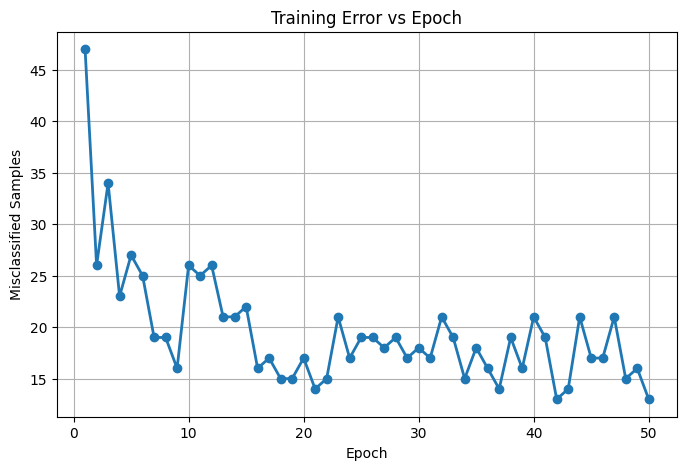

In [ ]:
# Plots to give us more insight
# Training error v Epoch (Misclassified Samples)
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(misclassified_history01)+1),
    misclassified_history01,
    marker='o',
    linewidth=2
)
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)
plt.show()

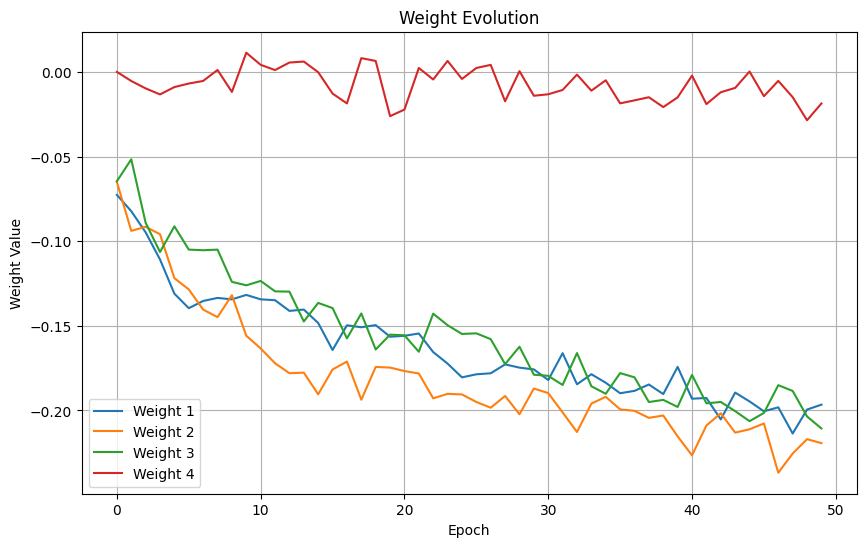

In [ ]:
# Weight v Epoch
weight_history = np.array(weight_history01)
plt.figure(figsize=(10,6))
for i in range(weight_history.shape[1]):
    plt.plot(weight_history[:, i], label=f"Weight {i+1}")
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.show()

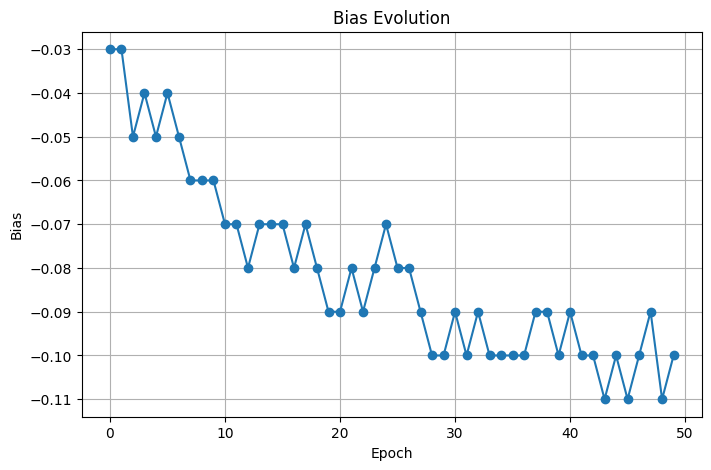

In [ ]:
# Bias v Epoch
plt.figure(figsize=(8,5))
plt.plot(
    bias_history01,
    marker='o'
)
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.show()

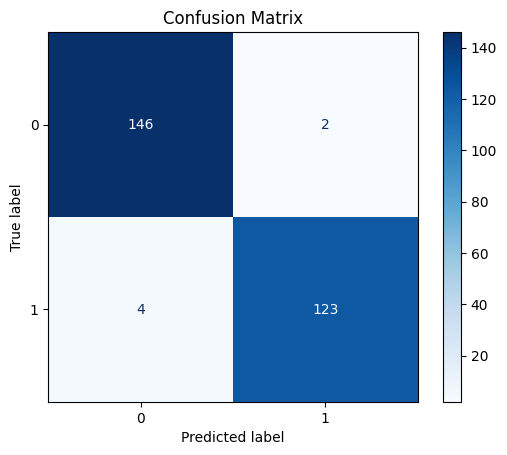

In [ ]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Additional Tasks
# Single Layer Perceptron with Learning Rate of 0.1
misclassified_history1 = []
weight_history1 = []
bias_history1 = []
learning_rate1 = 0.1

for epoch in range(max_epochs):

      misclassified = 0

      for x, y_true in zip(X_train, y_train):

          z = np.dot(weights, x) + bias
          prediction = step_function(z)

          error = y_true - prediction

          if error != 0:
              weights += learning_rate1 * error * x
              bias += learning_rate1 * error
              misclassified += 1

      misclassified_history1.append(misclassified)
      weight_history1.append(weights.copy())
      bias_history1.append(bias)

      print(f"Epoch {epoch+1}")
      print(f"Misclassified Samples : {misclassified}")
      print(f"Updated Weights : {weights}")
      print(f"Updated Bias : {bias}")
      print("-"*50)

      if misclassified == 0:
          print(f"Model converged after {epoch+1} epochs.")
          break

Epoch 1
Misclassified Samples : 41
Updated Weights : [-0.63384278 -0.69751261 -0.51289889  0.01990056]
Updated Bias : -0.20000000000000004
--------------------------------------------------
Epoch 2
Misclassified Samples : 34
Updated Weights : [-0.79804049 -0.86102557 -0.78730641  0.01904923]
Updated Bias : -0.4
--------------------------------------------------
Epoch 3
Misclassified Samples : 22
Updated Weights : [-0.97508216 -1.08181821 -0.73992056 -0.07410332]
Updated Bias : -0.4
--------------------------------------------------
Epoch 4
Misclassified Samples : 25
Updated Weights : [-1.05795273 -1.1334503  -0.76399884 -0.0550105 ]
Updated Bias : -0.5
--------------------------------------------------
Epoch 5
Misclassified Samples : 25
Updated Weights : [-1.01430302 -1.18441491 -1.04201408 -0.08307798]
Updated Bias : -0.6
--------------------------------------------------
Epoch 6
Misclassified Samples : 26
Updated Weights : [-1.27232929 -1.33452664 -0.97358531 -0.14719076]
Updated Bia

In [ ]:
# Single Layer Perceptron with Learning Rate of 0.001
misclassified_history001 = []
weight_history001 = []
bias_history001 = []
learning_rate001 = 0.001

for epoch in range(max_epochs):

      misclassified = 0

      for x, y_true in zip(X_train, y_train):

          z = np.dot(weights, x) + bias
          prediction = step_function(z)

          error = y_true - prediction

          if error != 0:
              weights += learning_rate001 * error * x
              bias += learning_rate001 * error
              misclassified += 1

      misclassified_history001.append(misclassified)
      weight_history001.append(weights.copy())
      bias_history001.append(bias)

      print(f"Epoch {epoch+1}")
      print(f"Misclassified Samples : {misclassified}")
      print(f"Updated Weights : {weights}")
      print(f"Updated Bias : {bias}")
      print("-"*50)

      if misclassified == 0:
          print(f"Model converged after {epoch+1} epochs.")
          break

Epoch 1
Misclassified Samples : 12
Updated Weights : [-1.91397341 -2.24021303 -2.06123971 -0.10982189]
Updated Bias : -1.090000000000001
--------------------------------------------------
Epoch 2
Misclassified Samples : 13
Updated Weights : [-1.91980205 -2.24960654 -2.04867096 -0.11053477]
Updated Bias : -1.0830000000000017
--------------------------------------------------
Epoch 3
Misclassified Samples : 10
Updated Weights : [-1.92144996 -2.25216537 -2.04600108 -0.1099902 ]
Updated Bias : -1.0790000000000022
--------------------------------------------------
Epoch 4
Misclassified Samples : 9
Updated Weights : [-1.92184475 -2.2531843  -2.04565037 -0.10997319]
Updated Bias : -1.0760000000000025
--------------------------------------------------
Epoch 5
Misclassified Samples : 9
Updated Weights : [-1.92223954 -2.25420323 -2.04529966 -0.10995619]
Updated Bias : -1.0730000000000028
--------------------------------------------------
Epoch 6
Misclassified Samples : 9
Updated Weights : [-1.92

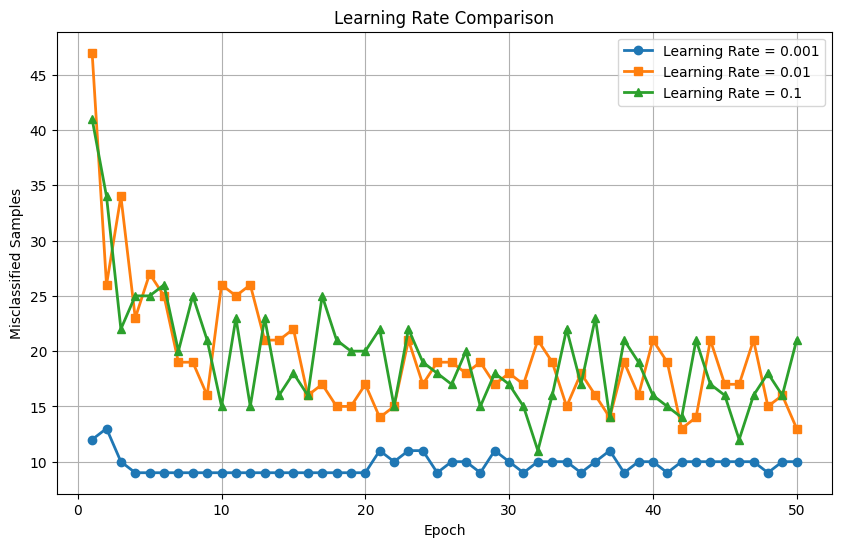

In [ ]:
# Plotting the Training Error v Epoch w.r.t all 3 runs
plt.figure(figsize=(10,6))
plt.plot(range(1, len(misclassified_history001)+1), misclassified_history001,
         marker='o', linewidth=2, label='Learning Rate = 0.001')
plt.plot(range(1, len(misclassified_history01)+1), misclassified_history01,
         marker='s', linewidth=2, label='Learning Rate = 0.01')
plt.plot(range(1, len(misclassified_history1)+1), misclassified_history1,
         marker='^', linewidth=2, label='Learning Rate = 0.1')
plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid(True)
plt.show()

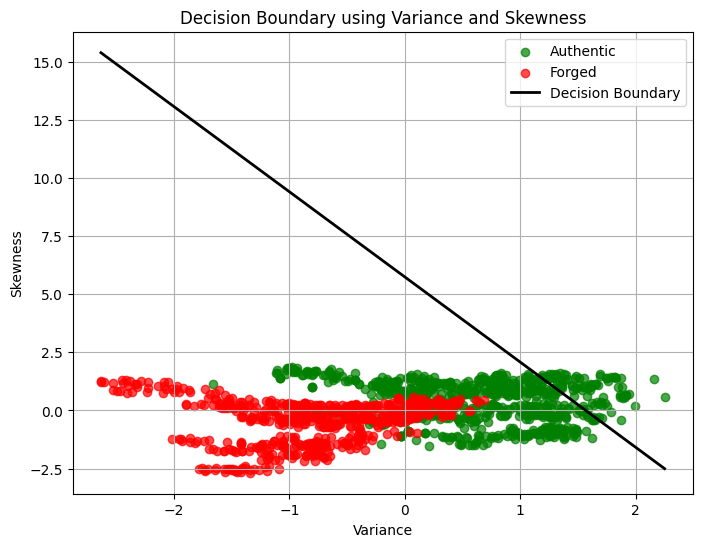

In [ ]:
# Decision Boundary using Variance and Skewness

# Select only Variance and Skewness
X_pair = X_scaled[:, [0, 1]]
y_pair = y.values

# Initialize Parameters
weights = np.zeros(2)
bias = 0
learning_rate = 0.01
epochs = 50

# Train Perceptron
for epoch in range(epochs):
    for x, y_true in zip(X_pair, y_pair):
        z = np.dot(weights, x) + bias
        prediction = step_function(z)
        error = y_true - prediction
        if error != 0:
            weights += learning_rate * error * x
            bias += learning_rate * error

# Plot Scatter
plt.figure(figsize=(8,6))

plt.scatter(
    X_pair[y_pair == 0, 0],
    X_pair[y_pair == 0, 1],
    color="green",
    label="Authentic",
    alpha=0.7
)

plt.scatter(
    X_pair[y_pair == 1, 0],
    X_pair[y_pair == 1, 1],
    color="red",
    label="Forged",
    alpha=0.7
)

# Decision Boundary
x_values = np.linspace(
    X_pair[:,0].min(),
    X_pair[:,0].max(),
    100
)

if abs(weights[1]) > 1e-8:

    y_values = -(weights[0] * x_values + bias) / weights[1]

    plt.plot(
        x_values,
        y_values,
        color="black",
        linewidth=2,
        label="Decision Boundary"
    )

plt.title("Decision Boundary using Variance and Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")

plt.legend()
plt.grid(True)

plt.show()

	AND Gate
	--------
Epoch 1
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0. 0.]
Updated Bias : -0.1


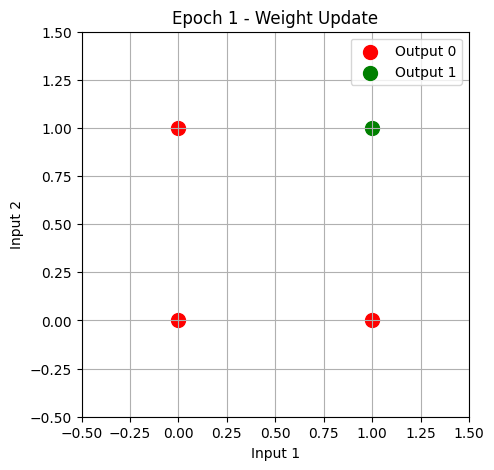

-----------------------------------
Input : [1 1]
Target : 1
Prediction : 0
Updated Weights : [0.1 0.1]
Updated Bias : 0.0


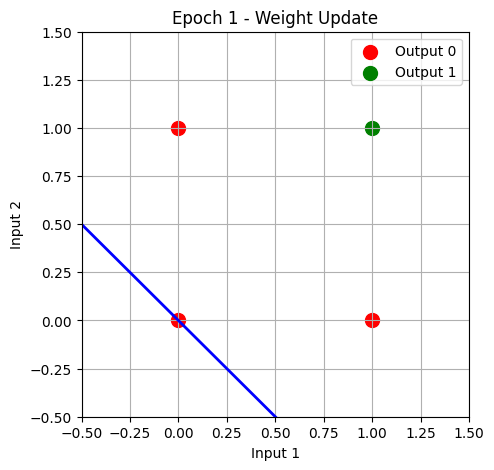

-----------------------------------
Epoch 2
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0.1 0.1]
Updated Bias : -0.1


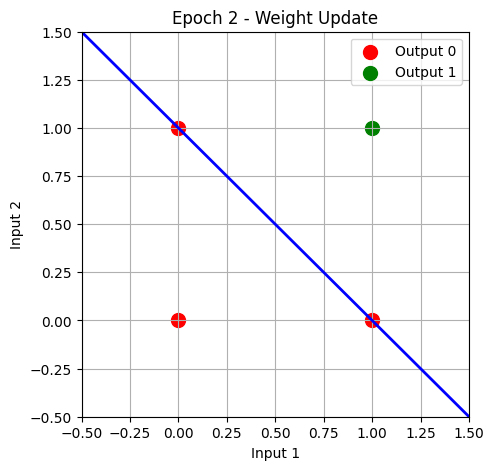

-----------------------------------
Input : [0 1]
Target : 0
Prediction : 1
Updated Weights : [0.1 0. ]
Updated Bias : -0.2


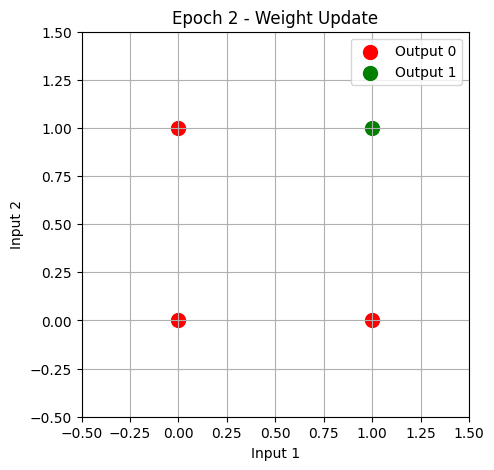

-----------------------------------
Input : [1 1]
Target : 1
Prediction : 0
Updated Weights : [0.2 0.1]
Updated Bias : -0.1


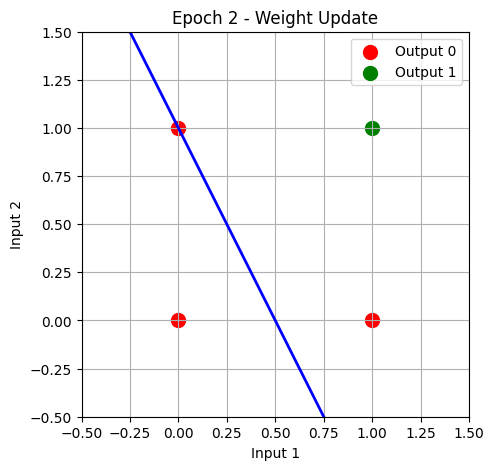

-----------------------------------
Epoch 3
Input : [0 1]
Target : 0
Prediction : 1
Updated Weights : [0.2 0. ]
Updated Bias : -0.2


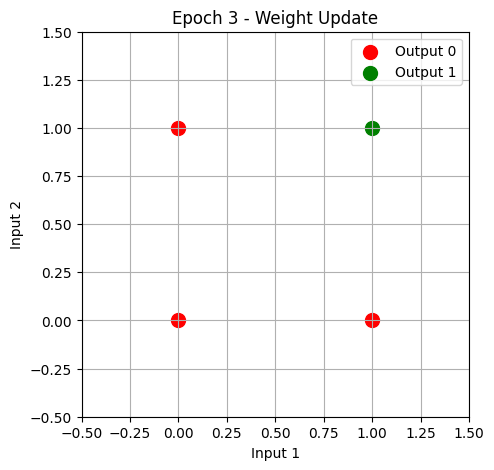

-----------------------------------
Input : [1 0]
Target : 0
Prediction : 1
Updated Weights : [0.1 0. ]
Updated Bias : -0.30000000000000004


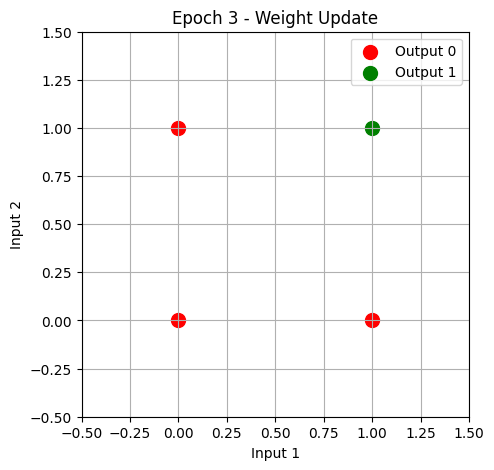

-----------------------------------
Input : [1 1]
Target : 1
Prediction : 0
Updated Weights : [0.2 0.1]
Updated Bias : -0.20000000000000004


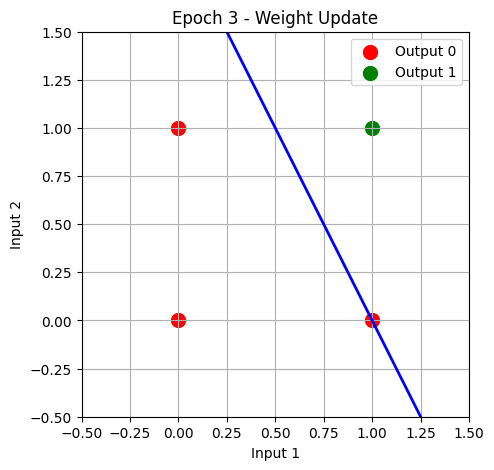

-----------------------------------
Epoch 4

Perceptron Converged!

Final Weights : [0.2 0.1]
Final Bias : -0.20000000000000004



	OR Gate
	-------
Epoch 1
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0. 0.]
Updated Bias : -0.1


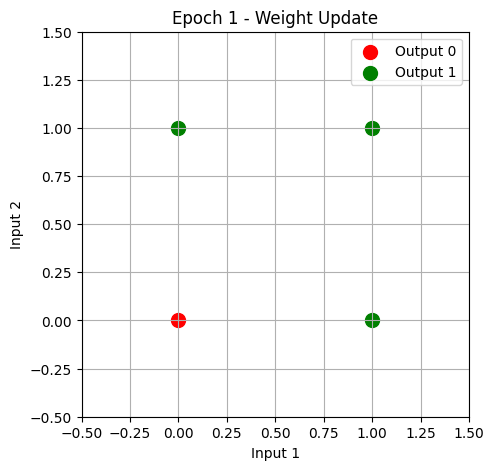

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.0


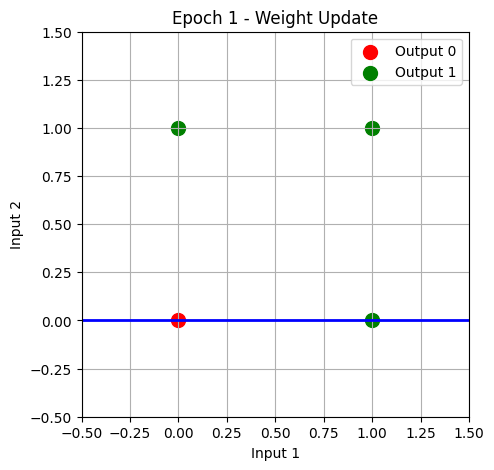

-----------------------------------
Epoch 2
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0.  0.1]
Updated Bias : -0.1


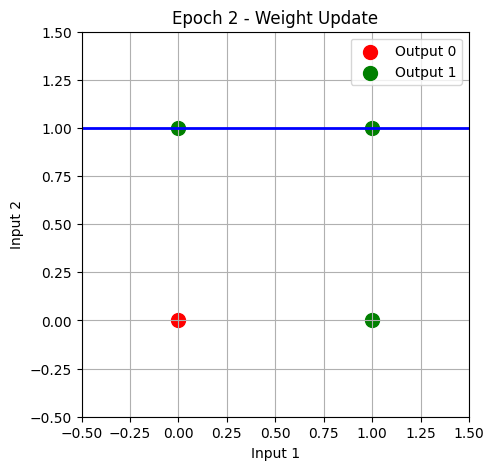

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.1 0.1]
Updated Bias : 0.0


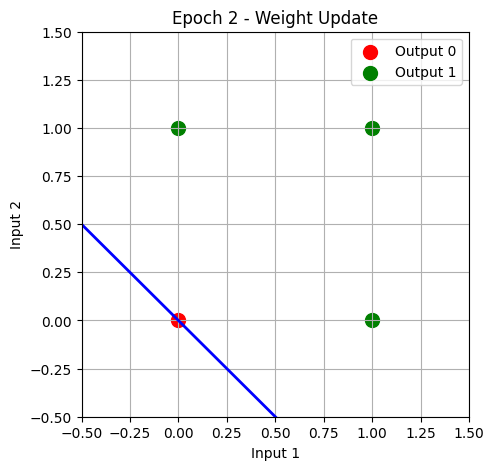

-----------------------------------
Epoch 3
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0.1 0.1]
Updated Bias : -0.1


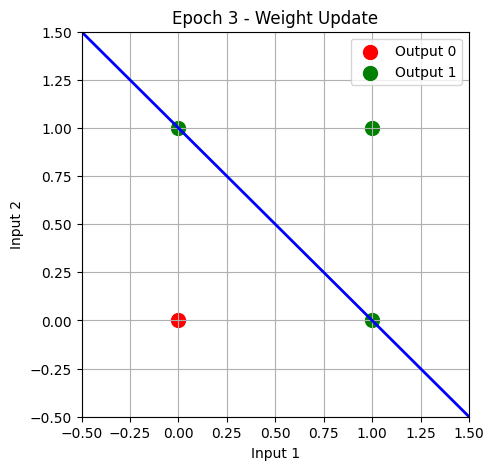

-----------------------------------
Epoch 4

Perceptron Converged!

Final Weights : [0.1 0.1]
Final Bias : -0.1



	XOR Gate
	-------
Epoch 1
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0. 0.]
Updated Bias : -0.1


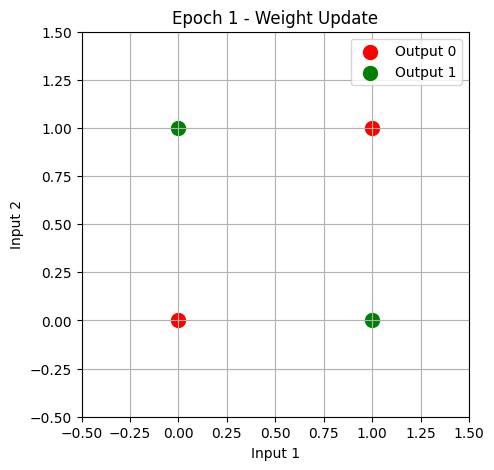

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.0


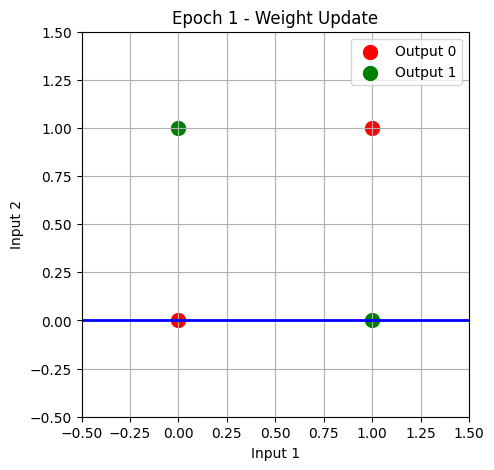

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


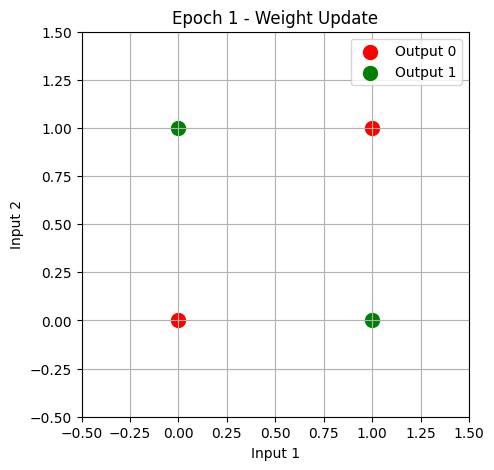

-----------------------------------
Epoch 2
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


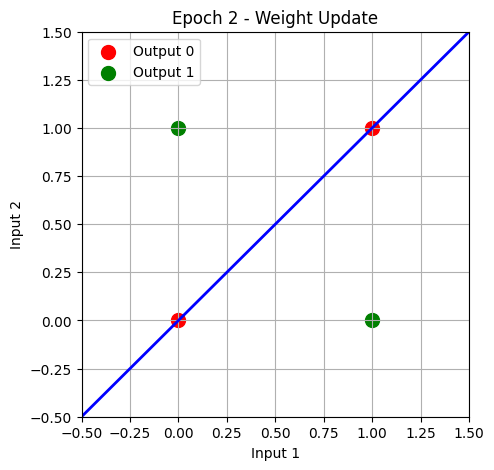

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


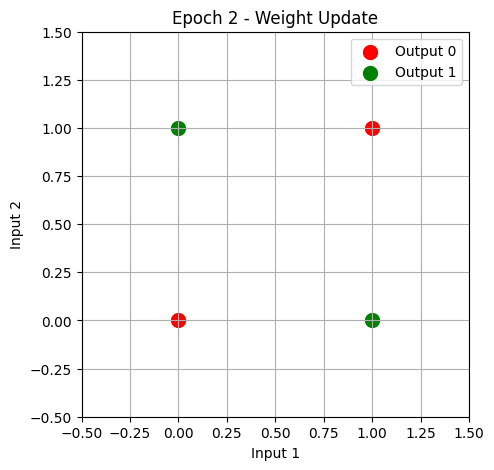

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


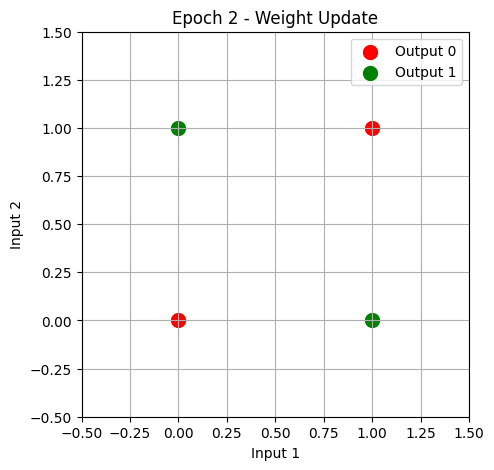

-----------------------------------
Epoch 3
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


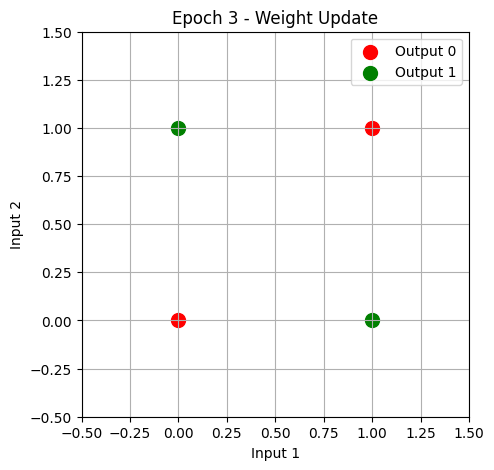

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


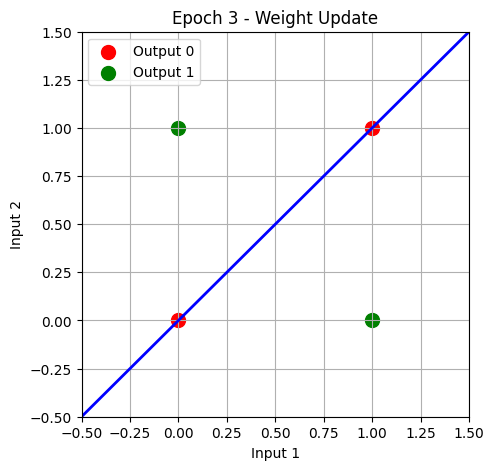

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


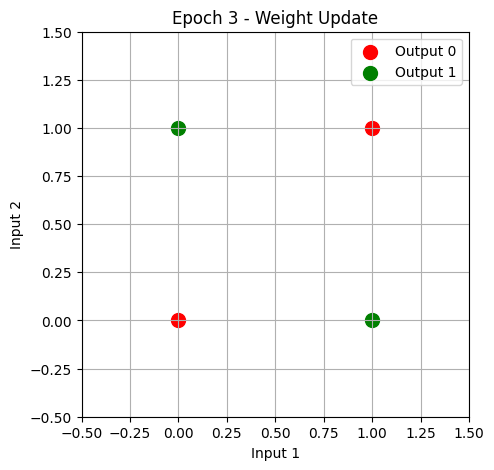

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


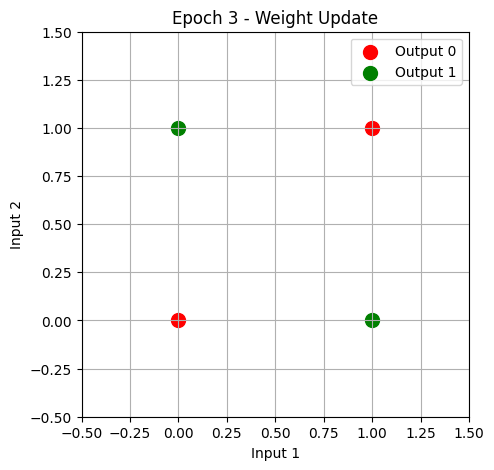

-----------------------------------
Epoch 4
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


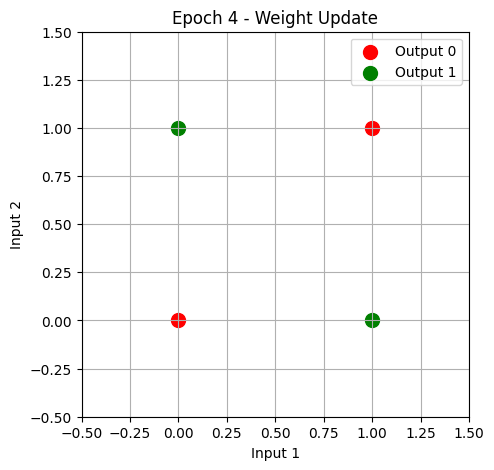

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


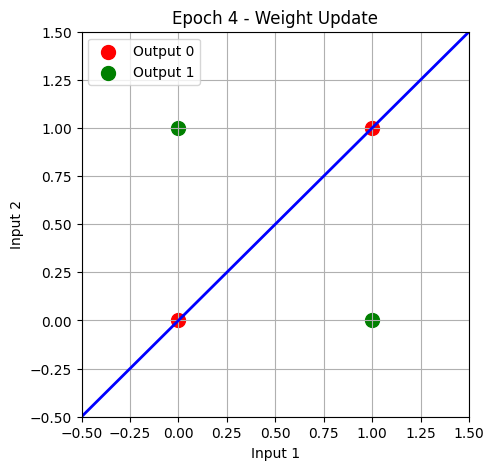

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


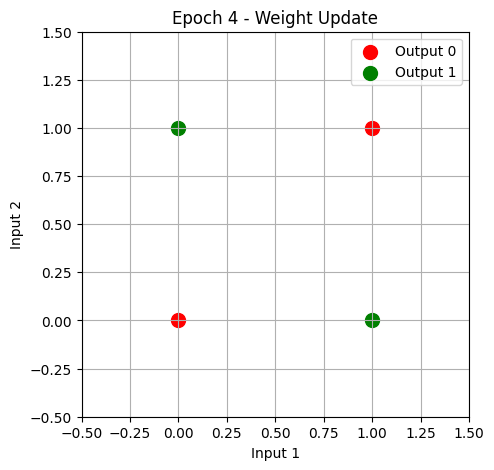

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


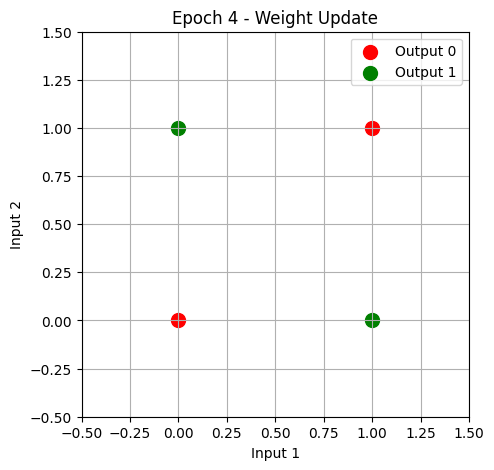

-----------------------------------
Epoch 5
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


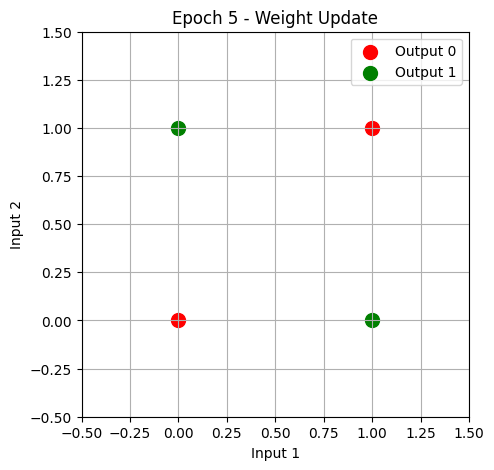

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


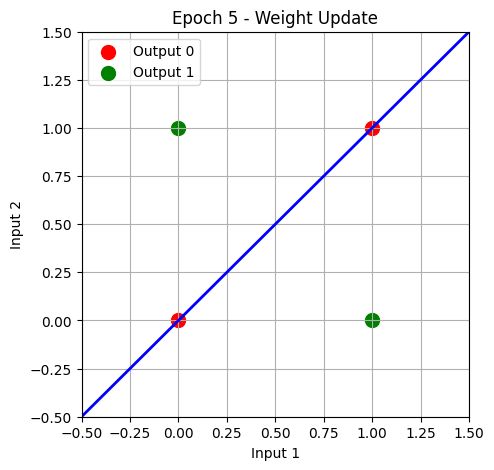

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


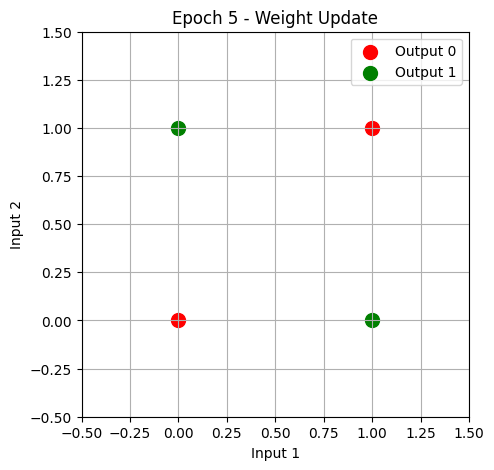

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


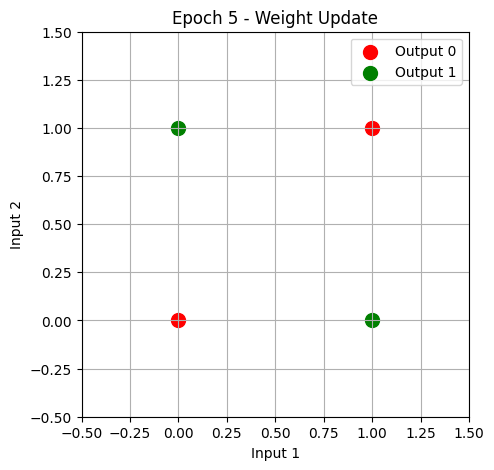

-----------------------------------
Epoch 6
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


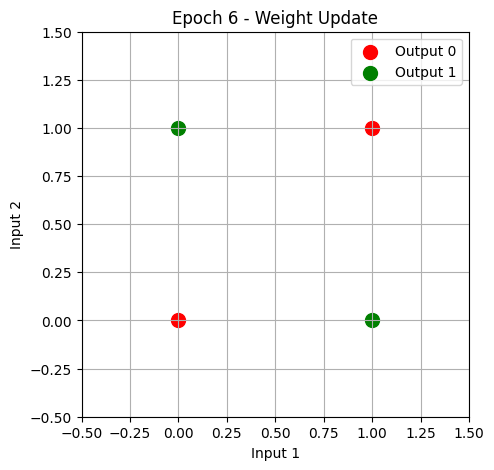

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


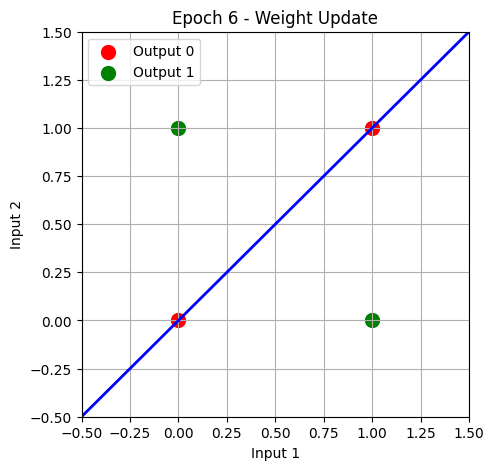

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


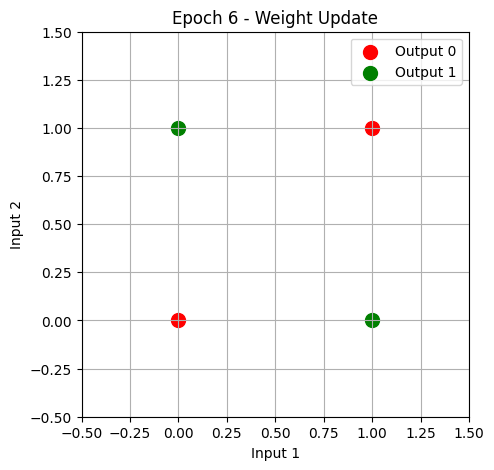

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


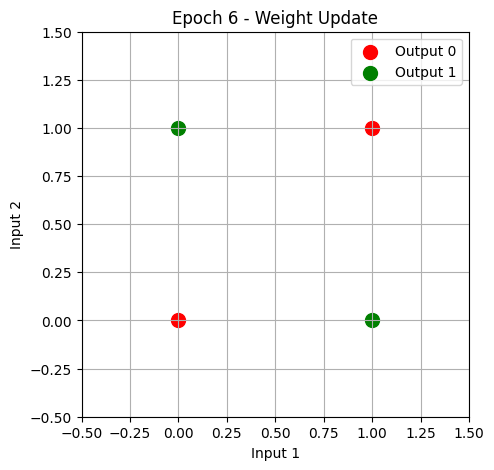

-----------------------------------
Epoch 7
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


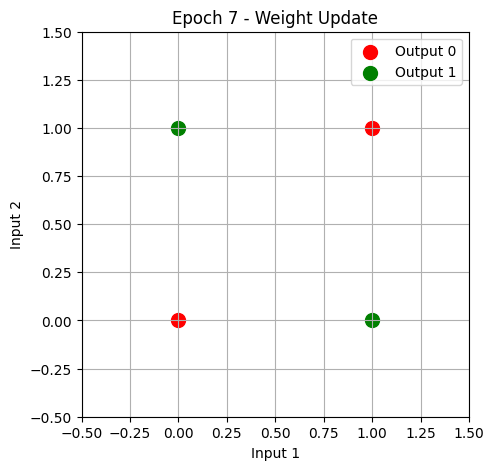

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


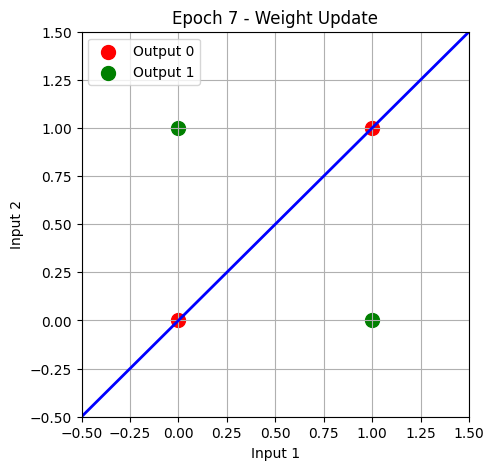

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


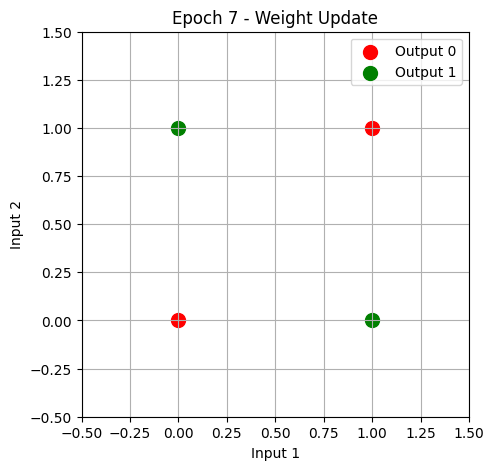

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


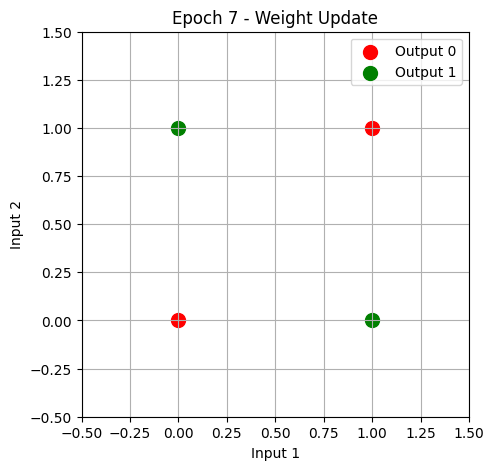

-----------------------------------
Epoch 8
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


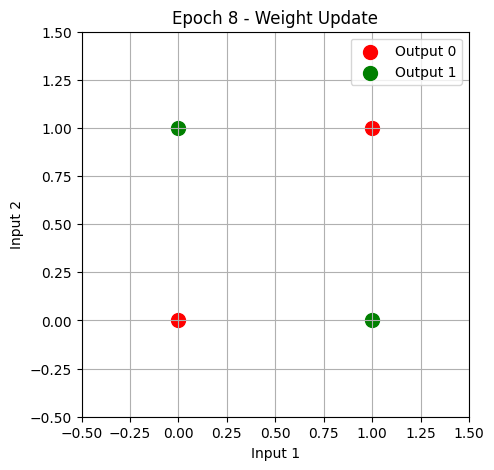

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


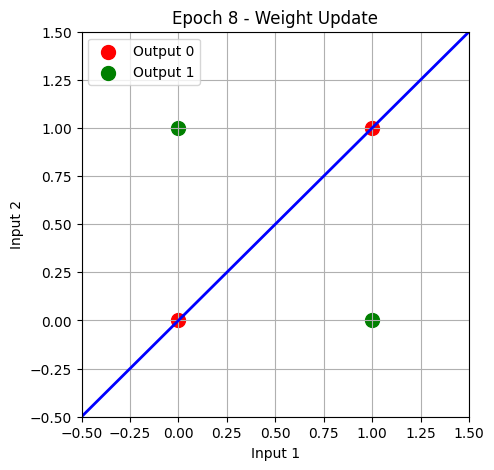

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


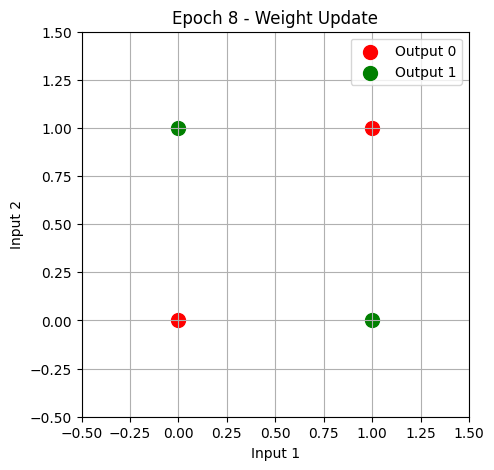

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


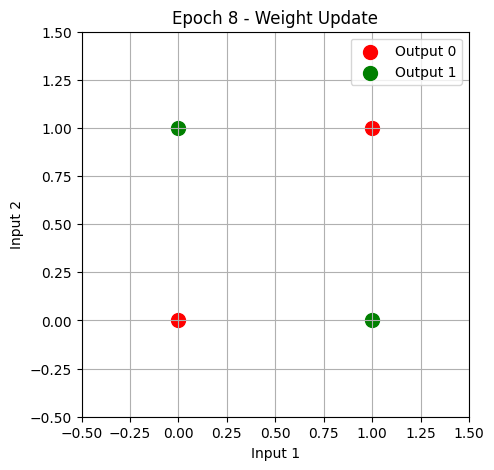

-----------------------------------
Epoch 9
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


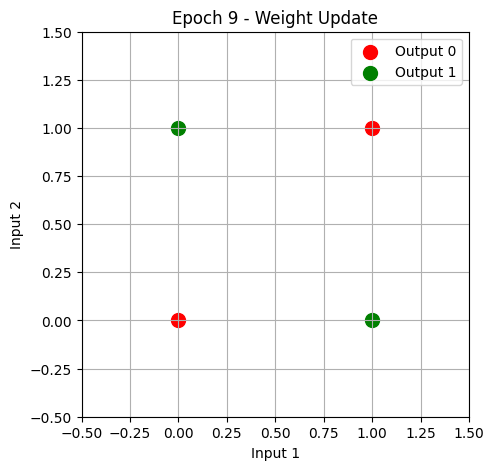

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


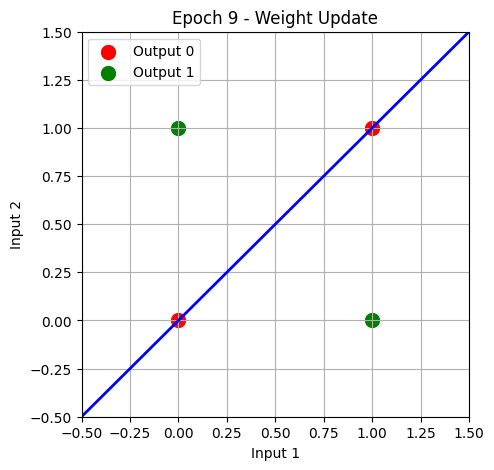

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


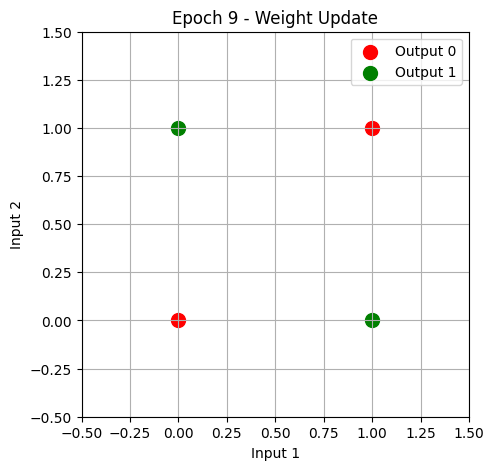

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


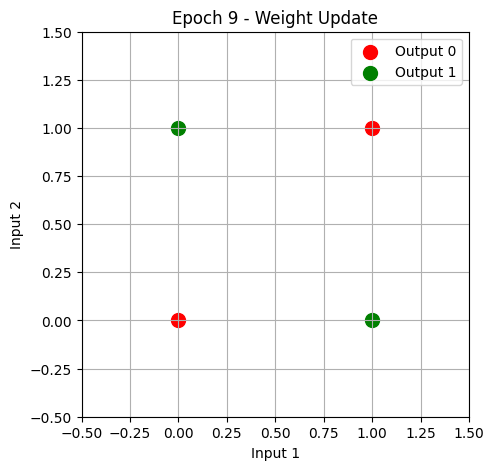

-----------------------------------
Epoch 10
Input : [0 0]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : -0.1


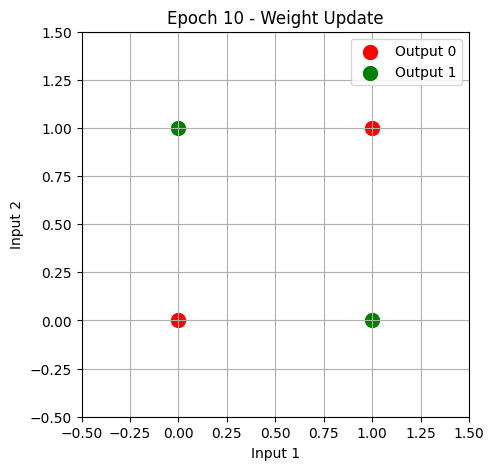

-----------------------------------
Input : [0 1]
Target : 1
Prediction : 0
Updated Weights : [-0.1  0.1]
Updated Bias : 0.0


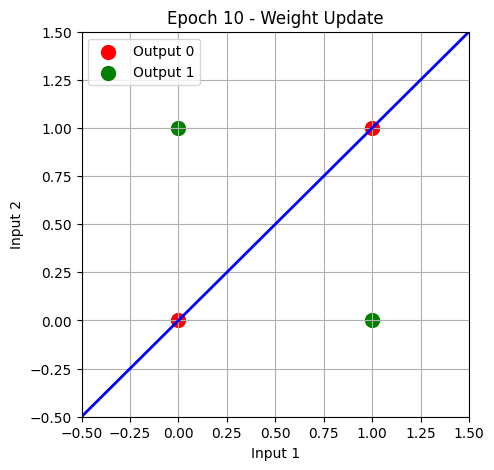

-----------------------------------
Input : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.1


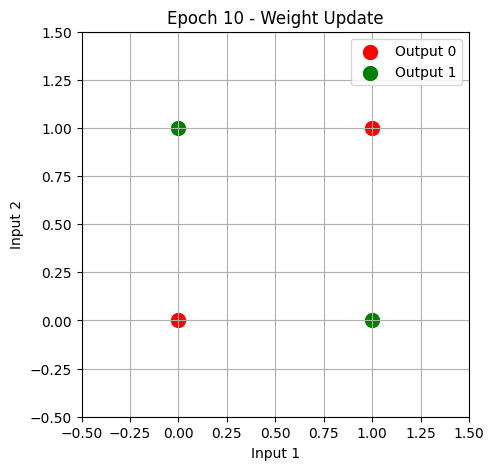

-----------------------------------
Input : [1 1]
Target : 0
Prediction : 1
Updated Weights : [-0.1  0. ]
Updated Bias : 0.0


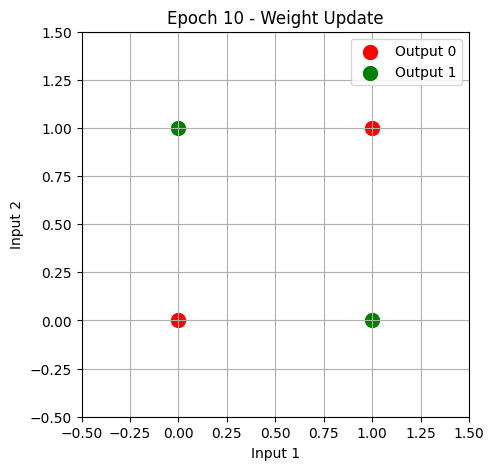

-----------------------------------

Final Weights : [-0.1  0. ]
Final Bias : 0.0


In [ ]:
# Simple Logic Gates trained using Single Layer Perceptron
# AND, OR, XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
yA = np.array([0, 0, 0, 1])
yO = np.array([0, 1, 1, 1])
yX = np.array([0, 1, 1, 0])

def logicgates(X,y):
  # Plot Decision Boundary
  def plot_decision_boundary(weights, bias, title):
      plt.figure(figsize=(5,5))
      plt.scatter(
          X[y == 0, 0],
          X[y == 0, 1],
          color="red",
          s=100,
          label="Output 0"
      )
      plt.scatter(
          X[y == 1, 0],
          X[y == 1, 1],
          color="green",
          s=100,
          label="Output 1"
      )
      x1 = np.linspace(-0.5, 1.5, 100)
      if abs(weights[1]) > 0.000001:
          x2 = -(weights[0] * x1 + bias) / weights[1]
          plt.plot(x1, x2, color="blue", linewidth=2)
      plt.xlim(-0.5, 1.5)
      plt.ylim(-0.5, 1.5)
      plt.xlabel("Input 1")
      plt.ylabel("Input 2")
      plt.title(title)
      plt.grid(True)
      plt.legend()
      plt.show()

  # Initialize Parameters
  weights = np.zeros(2)
  bias = 0
  learning_rate = 0.1
  epochs = 10

  # Perceptron Training
  for epoch in range(epochs):
      print("Epoch", epoch + 1)
      errors = 0
      for x, y_true in zip(X, y):
          z = np.dot(weights, x) + bias
          prediction = step_function(z)
          error = y_true - prediction
          if error != 0:
              weights = weights + learning_rate * error * x
              bias = bias + learning_rate * error
              errors += 1
              print("Input :", x)
              print("Target :", y_true)
              print("Prediction :", prediction)
              print("Updated Weights :", weights)
              print("Updated Bias :", bias)
              plot_decision_boundary(
                  weights,
                  bias,
                  f"Epoch {epoch + 1} - Weight Update"
              )
              print("-----------------------------------")

      if errors == 0:

          print("\nPerceptron Converged!")
          break

  print("\nFinal Weights :", weights)
  print("Final Bias :", bias)

print("\tAND Gate")
print("\t--------")
logicgates(X,yA)
print("\n\n\n\tOR Gate")
print("\t-------")
logicgates(X,yO)
print("\n\n\n\tXOR Gate")
print("\t-------")
logicgates(X,yX)

Epoch 1
Input : [1]
Target : 0
Prediction : 1
Updated Weights : [-0.1]
Updated Bias : -0.1


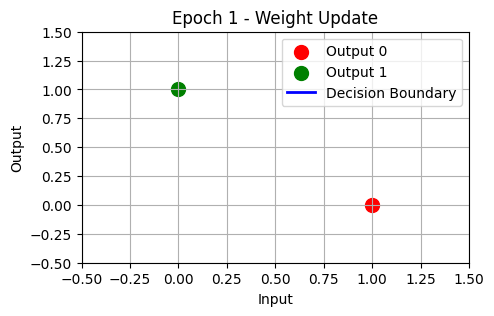

--------------------------------------------------
Epoch 2
Input : [0]
Target : 1
Prediction : 0
Updated Weights : [-0.1]
Updated Bias : 0.0


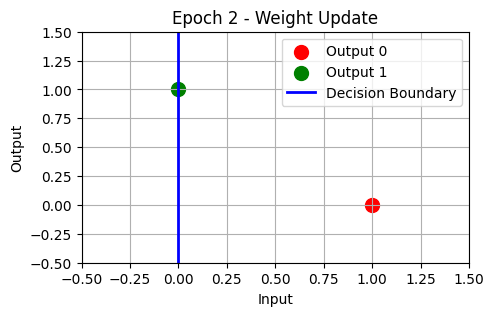

--------------------------------------------------
Epoch 3

Perceptron Converged!

Final Weights : [-0.1]
Final Bias : 0.0


In [ ]:
# NOT dataset
X = np.array([
    [0],
    [1]
])
y = np.array([1, 0])

def plot_not(weights, bias, title):
    plt.figure(figsize=(5,3))
    plt.scatter(
        X[y == 0],
        y[y == 0],
        color="red",
        s=100,
        label="Output 0"
    )
    plt.scatter(
        X[y == 1],
        y[y == 1],
        color="green",
        s=100,
        label="Output 1"
    )
    if abs(weights[0]) > 0.000001:
        boundary = -bias / weights[0]
        plt.axvline(
            x=boundary,
            color="blue",
            linewidth=2,
            label="Decision Boundary"
        )
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

weights = np.zeros(1)
bias = 0
learning_rate = 0.1
epochs = 10
for epoch in range(epochs):
    print("Epoch", epoch + 1)
    errors = 0
    for x, y_true in zip(X, y):
        z = np.dot(weights, x) + bias
        prediction = step_function(z)
        error = y_true - prediction
        if error != 0:
            weights = weights + learning_rate * error * x
            bias = bias + learning_rate * error
            errors += 1
            print("Input :", x)
            print("Target :", y_true)
            print("Prediction :", prediction)
            print("Updated Weights :", weights)
            print("Updated Bias :", bias)
            plot_not(
                weights,
                bias,
                f"Epoch {epoch + 1} - Weight Update"
            )
            print("-"*50)
    if errors == 0:
        print("\nPerceptron Converged!")
        break
print("\nFinal Weights :", weights)
print("Final Bias :", bias)